In [1]:
import numpy as np
import sympy as sp
from mes_packages import *
from mes_packages.quadrature import quadrature_triangle_ref_2D

In [2]:
w_2D,x_2D,y_2D = quadrature_triangle_ref_2D(5)
print(sum(w_2D))
print(x_2D)
print(y_2D)

0.49999999999999983
[0.04691008 0.04691008 0.04691008 0.04691008 0.04691008 0.23076534
 0.23076534 0.23076534 0.23076534 0.23076534 0.5        0.5
 0.5        0.5        0.5        0.76923466 0.76923466 0.76923466
 0.76923466 0.76923466 0.95308992 0.95308992 0.95308992 0.95308992
 0.95308992]
[0.04470952 0.21994012 0.47654496 0.7331498  0.9083804  0.03608486
 0.1775127  0.38461733 0.59172195 0.7331498  0.02345504 0.11538267
 0.25       0.38461733 0.47654496 0.01082522 0.05325264 0.11538267
 0.1775127  0.21994012 0.00220056 0.01082522 0.02345504 0.03608486
 0.04470952]


# Construction du maillage



=== Vérification de l'orientation des triangles ===
Nombre total de triangles: 276

Nombre de triangles corrigés: 0/276
Tous les triangles étaient déjà correctement orientés True
Nombre d'éléments : 276
Nombre de sommets : 176


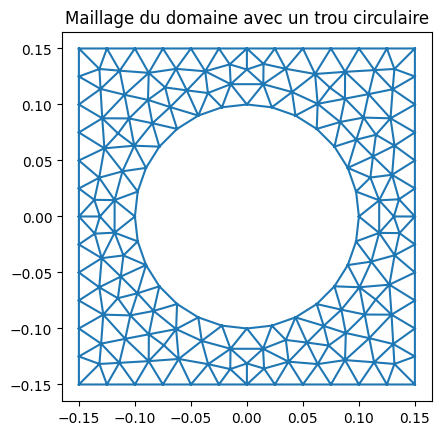

In [3]:
mesh = create_mesh_circle_in_square(radius=0.1, square_size=0.3, mesh_size=0.025)
# Recuperation de la géométrie du maillage
plot_mesh(mesh)



# Test du loc to glob 
On affiche ddl par ddl le nombre d'éléments auquel il appartient 

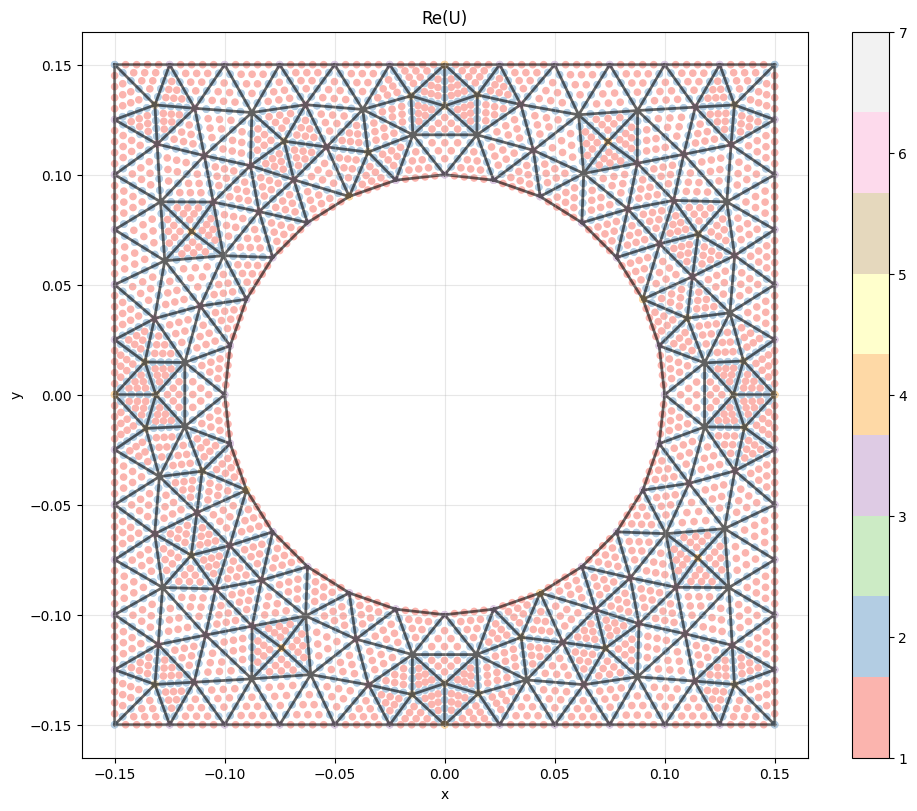

In [4]:
ordre =5
compteur =nombre_DDL_CG_par_DDL_DG(mesh,ordre)

## Assemblage des différentes matrices

In [ ]:
func = lambda x, y: 1  # Fonction de test (constante)
MASSE_CG = assemble_volume(mesh, ordre, func, "u", "v", methode="CG")
# ou
# MASSE_CG = build_masse_CG(mesh, ordre, verbose=False)

NameError: name 'func' is not defined

In [ ]:
RIGIDITE_CGx = assemble_volume(mesh, ordre, func, "dxu", "dxv", methode="CG")
RIGIDITE_CGy = assemble_volume(mesh, ordre, func, "dyu", "dyv", methode="CG")
# ou 
# RIGIDITE_CG = build_rigidite_CG(mesh, ordre, verbose=False)


In [ ]:
MASSE_BORD_CG = build_masse_frontiere_CG(mesh, ordre) 

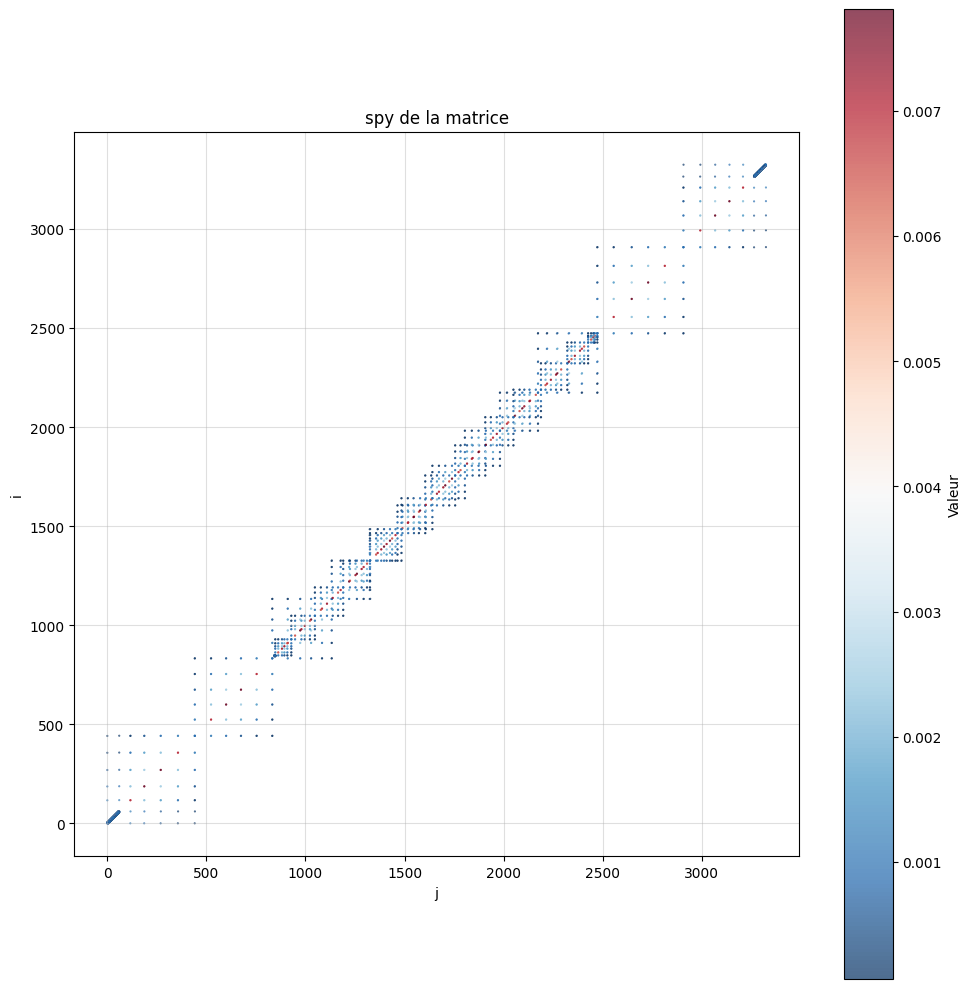

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'spy de la matrice'}, xlabel='j', ylabel='i'>)

In [ ]:
MASSE_BORD_CG.spy()

In [ ]:
# Résolution du problème de Fourier sur les frontières intérieures et extérieures
lambda_waves = 1
kappa = 2 * np.pi / lambda_waves
alpha = 1j * kappa
# Création de la matrice globale C0
taille_MAT = nombre_dof_CG(mesh, ordre)
Nnz = RIGIDITE_CGx.nnz + RIGIDITE_CGy.nnz + MASSE_CG.nnz + MASSE_BORD_CG.nnz
MAT_EF_CG = COOMatrix(taille_MAT, taille_MAT, Nnz)
# Assemblage des matrices de masse et rigidité dans la matrice globale
MAT_EF_CG = MAT_EF_CG + RIGIDITE_CGx
MAT_EF_CG = MAT_EF_CG + RIGIDITE_CGy
kappa2_MASSE_CG = kappa**2 * MASSE_CG
MAT_EF_CG =MAT_EF_CG - kappa2_MASSE_CG
ik_MASSE_BORD_CG = alpha * MASSE_BORD_CG
MAT_EF_CG = MAT_EF_CG + ik_MASSE_BORD_CG
# Construction du terme source 
# f(x,y) = exp(ikx) sur la frontière en symbolique

# Création du second membre

(0.05886685744977046+0j) 0.05858407346410206
(0.05886685744977046+0j)


In [ ]:
x, y = sp.symbols('x y')
f_source_sym = sp.exp(1j * kappa * x)


In [ ]:

f_source, dfx_source, dfy_source = build_f_and_grads(f_source_sym, (x, y))
F_CG = termes_source_frontiere_CG(f_source,mesh, ordre)
dn_F_CG = termes_source_frontiere_gradn_CG(dfx_source, dfy_source, mesh, ordre)

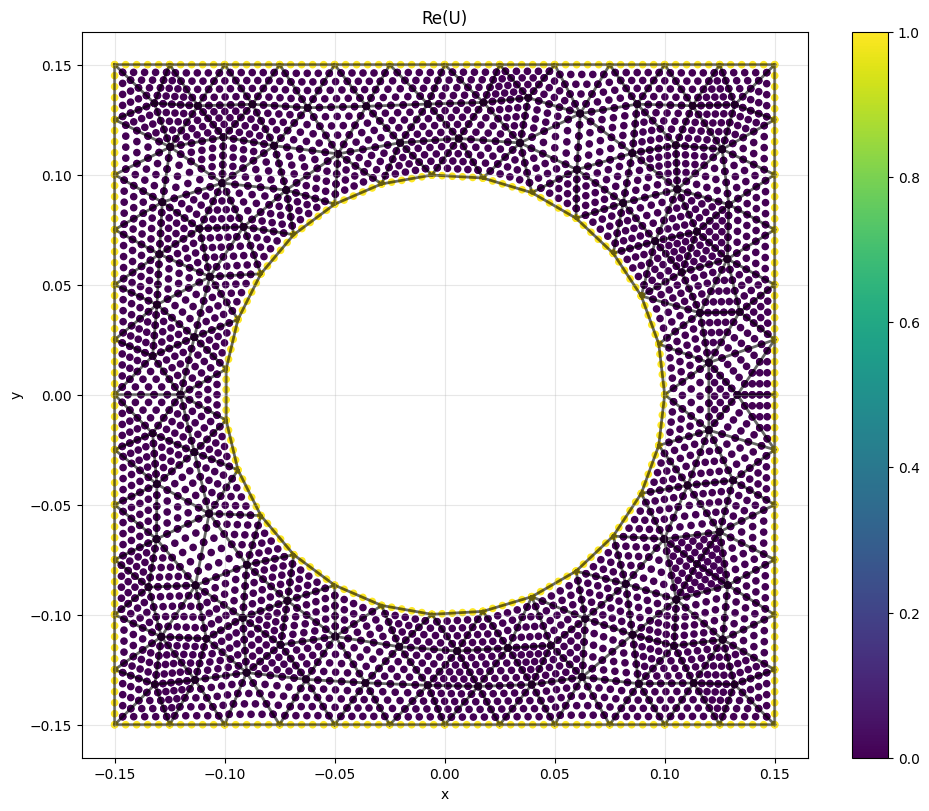

In [ ]:
plot_support_terme_source(F_CG, mesh, ordre)

# Résolution

In [ ]:
# Conversion de la matrice en format compressé pour la résolution
#MAT_EF_CG.create_COO()  # Crée la matrice scipy COO si ce n'est pas déjà fait
#MAT_EF_CG.to_csc()      # Conversion en format CSC (Compressed Sparse Column)




# Résolution du système linéaire K_CG * U_sol = F_CG
U_sol = MAT_EF_CG.solve(dn_F_CG+alpha*F_CG)


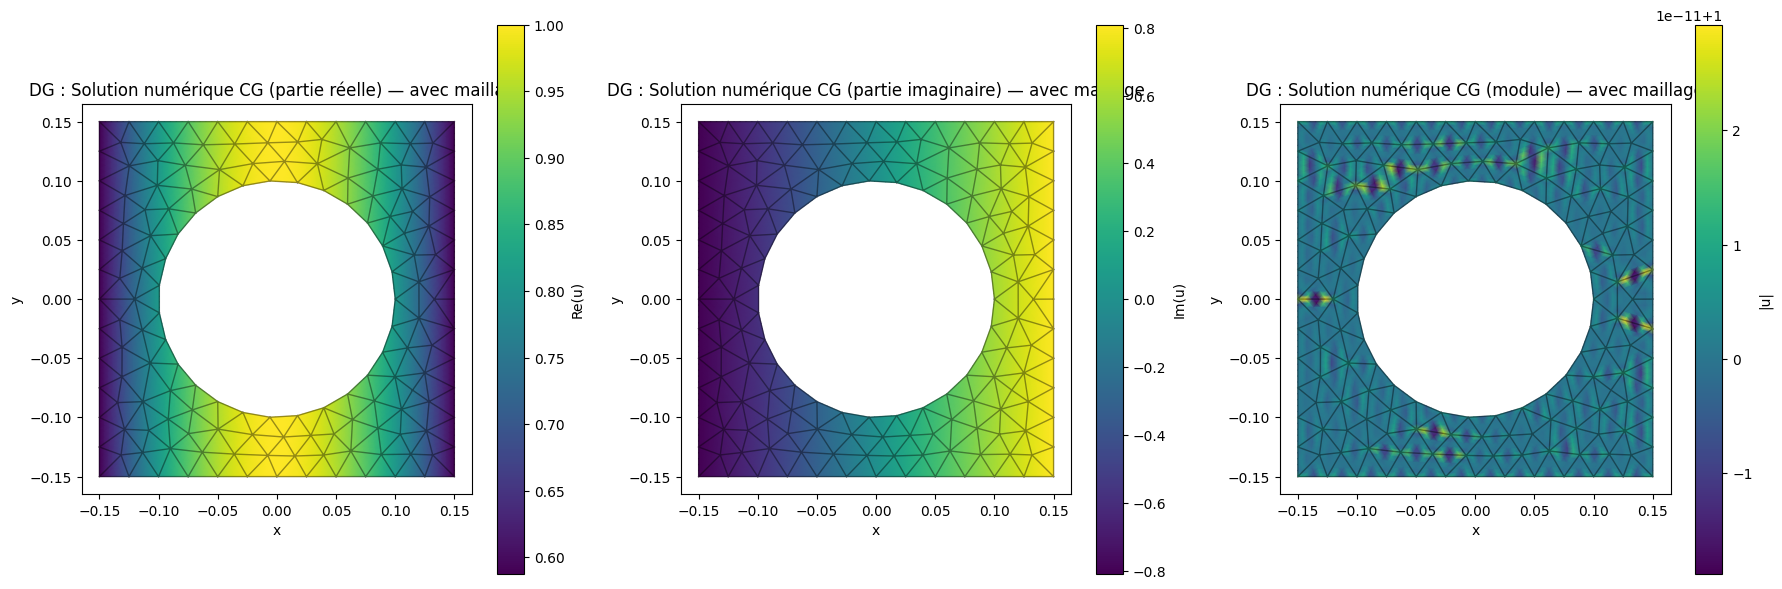

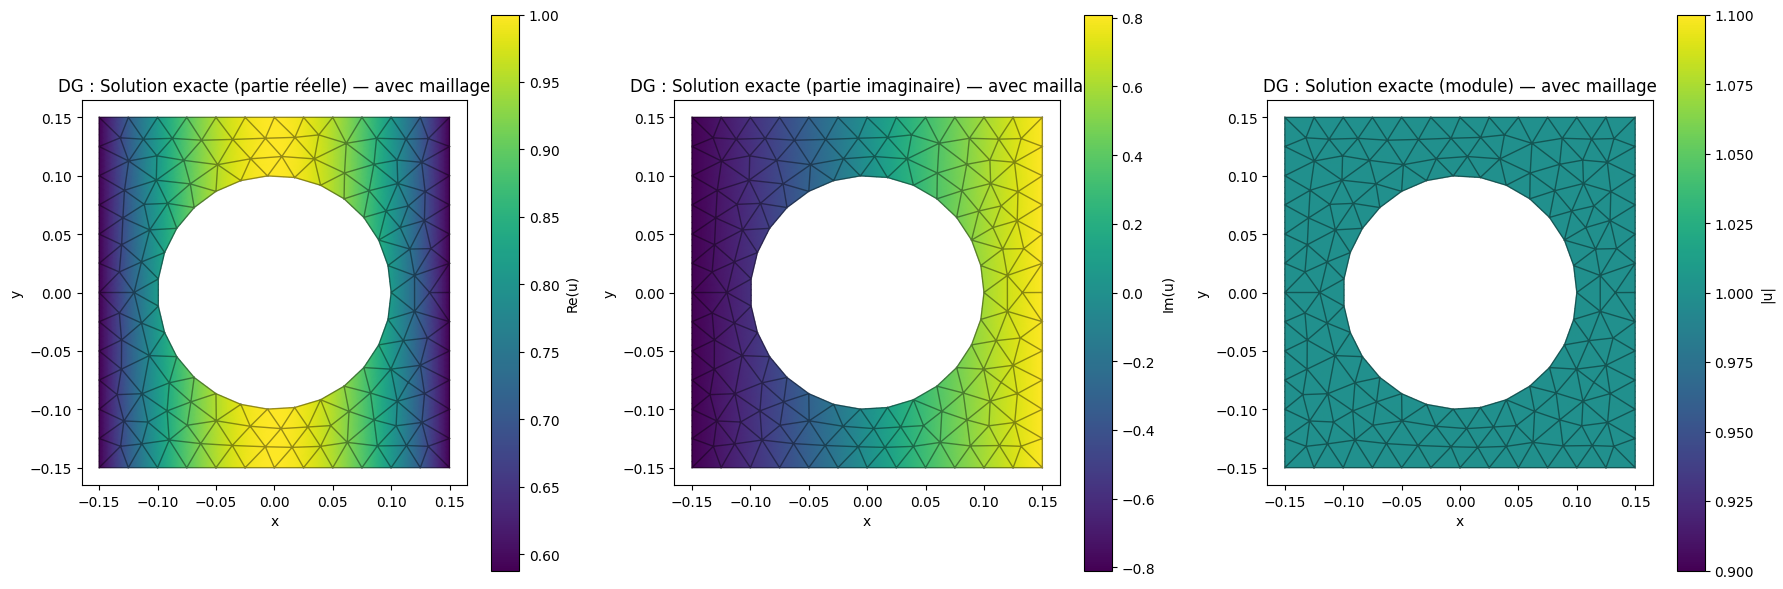

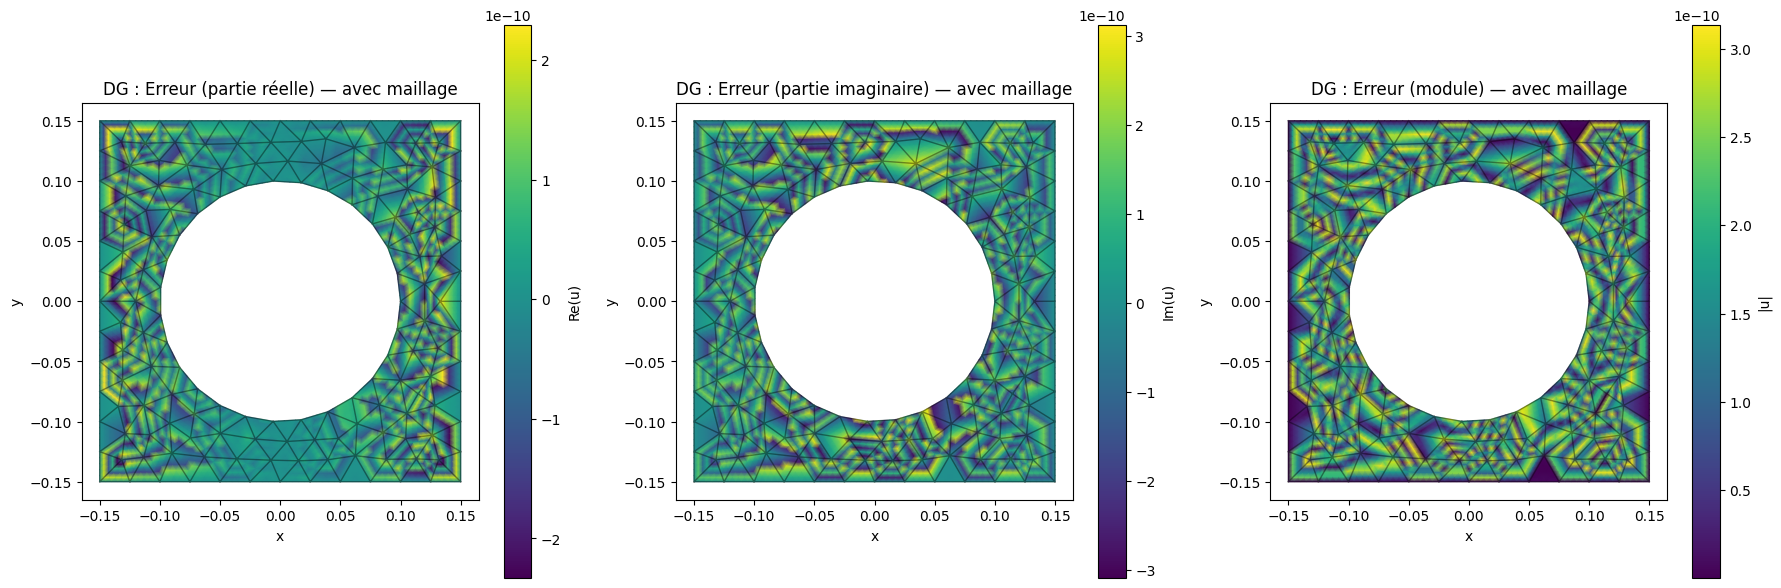

In [ ]:

# Visualisation du résultat
plot_nodal_vector_CG(U_sol, mesh, ordre, "Solution numérique CG")

U_ex = build_nodal_vector_CG(f_source,mesh,ordre)
plot_nodal_vector_CG(U_ex, mesh, ordre, "Solution exacte")

# Représentation de l'erreur
U_err = U_sol - U_ex
plot_nodal_vector_CG(U_err, mesh, ordre, "Erreur")



## Assemblage de la matrice de rigidité (C0)

La **matrice de rigidité** $K_{C0}$ correspond à la discrétisation du Laplacien (ou opérateur de diffusion) en éléments finis continus. Elle est définie par :

$$
K_{i,j} = \int_\Omega \nabla \varphi_i \cdot \nabla \varphi_j \, dx
$$

où $\varphi_i$, $\varphi_j$ sont les fonctions de base globales associées aux degrés de liberté (DDL) du maillage.

### Étapes de l’assemblage

1. **Boucle sur les triangles** :  
   Pour chaque triangle $T$ du maillage, on calcule la matrice de rigidité locale $K^{(T)}$.

2. **Calcul de la matrice locale** :  
   $K^{(T)}$ est obtenue par transformation du triangle de référence vers le triangle réel, en tenant compte du jacobien et des dérivées des fonctions de base.

3. **Boucle sur les DDL locaux** :  
   Pour chaque couple de DDL locaux $(i_{loc}, j_{loc})$ du triangle $T$ :
   - On convertit les indices locaux en indices globaux via la table `loc_to_glob_CG`.
   - On ajoute la contribution locale à la matrice globale :
     $$
     K_{C0}[i_{glob}, j_{glob}] \mathrel{+}= K^{(T)}[i_{loc}, j_{loc}]
     $$
   - Si un DDL est partagé par plusieurs triangles, les contributions sont sommées automatiquement.


# Assemblage des matrices dans la numérotation continue

# Assemblage des matrices dans la numérotation continue

## Principe de l'assemblage en méthode C0

En **méthode C0** (Galerkin continue), contrairement à la méthode DG, les degrés de liberté (DDL) sont **partagés entre triangles adjacents**. Cela signifie qu'un même DDL physique (situé sur une arête ou un sommet commun) appartient à plusieurs triangles.

### Différence DG vs C0

| Méthode | DDL par triangle | DDL globaux | Assemblage |
|---------|------------------|-------------|------------|
| **DG** | $N_{loc}$ privés | $N_{glob} = N_T \times N_{loc}$ | Chaque élément indépendant |
| **C0** | $N_{loc}$ partagés | $N_{glob} \ll N_T \times N_{loc}$ | Accumulation des contributions |

### Structure de `loc_to_glob_CG`

La table `loc_to_glob_CG[iT, iloc1, iloc2]` donne l'indice global du DDL local $(iloc1, iloc2)$ du triangle $iT$ :

$$
\text{loc\_to\_glob\_CG}[i_T, i_{loc1}, i_{loc2}] = i_{glob} \in \{0, \ldots, N_{glob}^{C0} - 1\}
$$

**Propriété clé** : Si deux triangles $T$ et $T'$ partagent un DDL à la même position $(x,y)$, alors :
$$
\text{loc\_to\_glob\_CG}[T, i_{loc1}, i_{loc2}] = \text{loc\_to\_glob\_CG}[T', i'_{loc1}, i'_{loc2}]
$$

### Assemblage des matrices en C0

Pour construire la matrice globale $\mathbf{M}^{C0}$, on suit le processus :

1. **Calcul des matrices locales** : Pour chaque triangle $T$, calculer $\mathbf{M}^{(T)}_{loc}$

2. **Parcours des DDL locaux** : Pour chaque couple de DDL locaux $(i_{loc}, j_{loc})$ du triangle $T$ :
   - Convertir $(m_1, n_1) \rightarrow i_{loc}$ et $(m_2, n_2) \rightarrow j_{loc}$ via `loc2D_to_loc1D`
   - Récupérer les indices globaux :
     $$
     i_{glob} = \text{loc\_to\_glob\_CG}[T, m_1, n_1]
     $$
     $$
     j_{glob} = \text{loc\_to\_glob\_CG}[T, m_2, n_2]
     $$

3. **Accumulation** : Ajouter la contribution locale à la matrice globale :
   $$
   M^{C0}_{i_{glob}, j_{glob}} \mathrel{+}= M^{(T)}_{i_{loc}, j_{loc}}
   $$

Le même couple $(i_{glob}, j_{glob})$ peut recevoir des contributions de plusieurs triangles (ceux qui partagent ces DDL). L'opérateur `+=` est essentiel.


# Assemblage du terme source

Dans la formulation variationnelle d’un problème aux éléments finis, le **terme source** correspond à l’intégrale du second membre (ou forçage) contre les fonctions de base :

$$
F_i = \int_{\partial\Omega} f(x, y) \, \varphi_i(x, y) \, ds_{x,y}
$$

où $f(x, y)$ est la fonction source (donnée du problème) et $\varphi_i$ la fonction de base associée au DDL $i$.

# Assemblage du second terme source

Dans la formulation variationnelle d’un problème aux éléments finis, le **terme source** correspond à l’intégrale du second membre (ou forçage) contre les fonctions de base :

$$
F_i = \int_{\partial \Omega} \nabla f(x, y)\cdot n(x,y) \, \varphi_i(x, y) \, ds_{x,dy}
$$

où $f(x, y)$ est la fonction source (donnée du problème) et $\varphi_i$ la fonction de base associée au DDL $i$.

